# NLP Pipeline — Phase 1
### Image OCR → Text Cleaning → Tokenisation → Stopwords → Lemmatisation → NER → Key Phrases → Dependency Parsing
---

## Imports

In [85]:
!pip install --upgrade certifi


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [86]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())



In [87]:
# ── Image / OCR ───────────────────────────────────────────────────────────
import cv2
import pytesseract

# ── Core NLP ──────────────────────────────────────────────────────────────
import spacy
from spacy import displacy
from IPython.display import display, HTML

# ── NLTK ──────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords',  quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('wordnet',    quiet=True)

# ── Utilities ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Load spaCy model
nlp = spacy.load('en_core_web_sm')



[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


---
## Image Input with OCR 

Image loaded successfully.
Shape (H, W, C): (2200, 1700, 3)


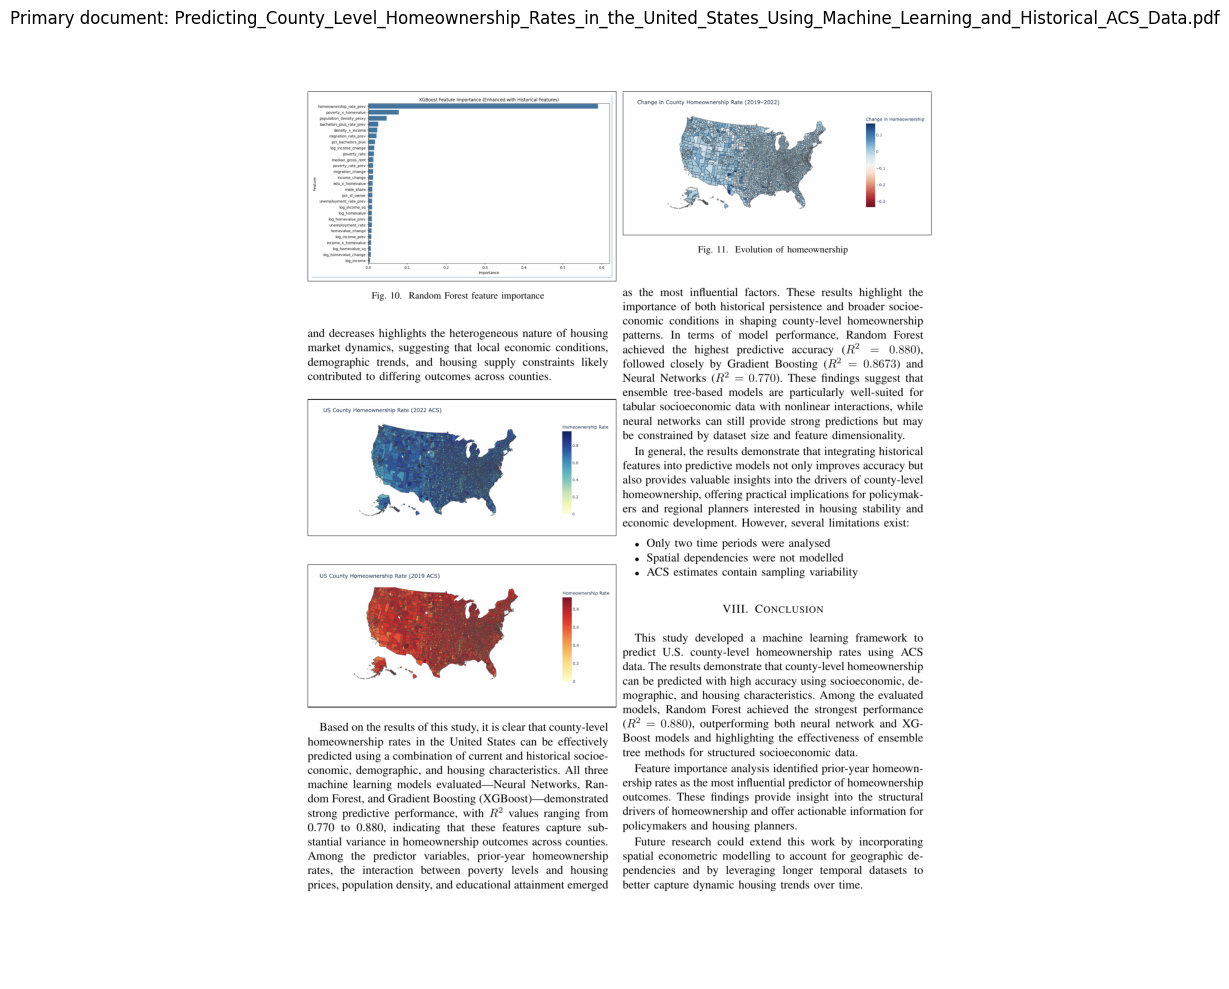

In [88]:
import cv2
import matplotlib.pyplot as plt
import os

from pdf2image import convert_from_path
import numpy as np

#Source: https://stackoverflow.com/questions/46184239/python-extract-a-pdf-page-as-a-jpeg   takes a PDF and convert each page to a image

# ── Input file (can be image OR PDF) ───────────────────────────────
PRIMARY_FILE = "Predicting_County_Level_Homeownership_Rates_in_the_United_States_Using_Machine_Learning_and_Historical_ACS_Data.pdf"   # change this freely

# ── Helper: load image or PDF ──────────────────────────────────────
def load_document(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    # ── Case 1: Image file ─────────────────────────
    if ext in [".png", ".jpg", ".jpeg", ".tif", ".bmp"]:
        img = cv2.imread(file_path)
        if img is None:
            raise FileNotFoundError(f"Could not load image: {file_path}")
        return img

    # ── Case 2: PDF file ───────────────────────────
    elif ext == ".pdf":
        pages = convert_from_path(file_path, dpi=200)

        # take first page (you can loop later if needed)
        page = pages[4]

        # convert PIL → OpenCV (RGB → BGR)
        img = cv2.cvtColor(np.array(page), cv2.COLOR_RGB2BGR)
        return img

    else:
        raise ValueError("Unsupported file type. Use image or PDF.")

# ── Load document ──────────────────────────────────────────────────
img = load_document(PRIMARY_FILE)

print("Image loaded successfully.")
print(f"Shape (H, W, C): {img.shape}")

# ── Display (BGR → RGB) ────────────────────────────────────────────
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Primary document: {PRIMARY_FILE}")
plt.tight_layout()
plt.show()


In [89]:
# ── OCR with Tesseract ────────────────────────────────────────────────────
# --oem 1  = LSTM neural network engine (Tesseract 5)
# --psm 6  = assume a uniform block of text
custom_config = r'--oem 1 --psm 6'

ocr_text = pytesseract.image_to_string(img, config=custom_config)

print('=== RAW OCR OUTPUT ===')
print(ocr_text)

=== RAW OCR OUTPUT ===
semeonrersip. ete prev XGBoost Feature Importance (Enhanced with Historical Features) Change in County Homeownership Rate (2019-2022)
abn Fig. 11. Evolution of homeownership
Fig. 10. Random Forest feature importance as the most influential factors. These results highlight the
importance of both historical persistence and broader socioe-
conomic conditions in shaping county-level homeownership
and decreases highlights the heterogeneous nature of housing patterns. In terms of model performance, Random Forest
market dynamics, suggesting that local economic conditions, achieved the highest predictive accuracy (R? = 0.880),
demographic trends, and housing supply constraints likely followed closely by Gradient Boosting (R? = 0.8673) and
contributed to differing outcomes across counties. Neural Networks (R? = 0.770). These findings suggest that
ensemble tree-based models are particularly well-suited for
US County Homeownership Rate (2022 ACS) tabular socioeconomic data 

---
## 1 Tokenisation
### 1a NLTK Tokenisation

In [90]:
# ── Tokenise the OCR text using NLTK word_tokenize ────────────────────────
text_tokens = word_tokenize(ocr_text)

print('=== NLTK TOKENS ===')
print(text_tokens)
print(f'\nTotal tokens: {len(text_tokens)}')

=== NLTK TOKENS ===
['semeonrersip', '.', 'ete', 'prev', 'XGBoost', 'Feature', 'Importance', '(', 'Enhanced', 'with', 'Historical', 'Features', ')', 'Change', 'in', 'County', 'Homeownership', 'Rate', '(', '2019-2022', ')', 'abn', 'Fig', '.', '11', '.', 'Evolution', 'of', 'homeownership', 'Fig', '.', '10', '.', 'Random', 'Forest', 'feature', 'importance', 'as', 'the', 'most', 'influential', 'factors', '.', 'These', 'results', 'highlight', 'the', 'importance', 'of', 'both', 'historical', 'persistence', 'and', 'broader', 'socioe-', 'conomic', 'conditions', 'in', 'shaping', 'county-level', 'homeownership', 'and', 'decreases', 'highlights', 'the', 'heterogeneous', 'nature', 'of', 'housing', 'patterns', '.', 'In', 'terms', 'of', 'model', 'performance', ',', 'Random', 'Forest', 'market', 'dynamics', ',', 'suggesting', 'that', 'local', 'economic', 'conditions', ',', 'achieved', 'the', 'highest', 'predictive', 'accuracy', '(', 'R', '?', '=', '0.880', ')', ',', 'demographic', 'trends', ',', 'and

### 1b. spaCy Tokenisation

In [91]:
# ── Tokenise with spaCy ───────────────────────────────────────────────────
doc = nlp(ocr_text)

print('=== spaCy TOKENS ===')
for token in doc:
    print(token.text, token.pos_, end=' | ')

print(f'\n\nTotal tokens: {len(doc)}')
print(f'Vocabulary size (en_core_web_sm): {len(doc.vocab)}')

=== spaCy TOKENS ===
semeonrersip PROPN | . PUNCT | ete NOUN | prev VERB | XGBoost PROPN | Feature PROPN | Importance PROPN | ( PUNCT | Enhanced VERB | with ADP | Historical PROPN | Features PROPN | ) PUNCT | Change NOUN | in ADP | County PROPN | Homeownership PROPN | Rate PROPN | ( PUNCT | 2019 NUM | - SYM | 2022 NUM | ) PUNCT | 
 SPACE | abn NOUN | Fig PROPN | . PUNCT | 11 NUM | . PUNCT | Evolution NOUN | of ADP | homeownership NOUN | 
 SPACE | Fig PROPN | . PROPN | 10 NUM | . PUNCT | Random PROPN | Forest PROPN | feature NOUN | importance NOUN | as ADP | the DET | most ADV | influential ADJ | factors NOUN | . PUNCT | These DET | results NOUN | highlight VERB | the DET | 
 SPACE | importance NOUN | of ADP | both PRON | historical ADJ | persistence NOUN | and CCONJ | broader ADJ | socioe- ADJ | 
 SPACE | conomic ADJ | conditions NOUN | in ADP | shaping VERB | county NOUN | - PUNCT | level NOUN | homeownership NOUN | 
 SPACE | and CCONJ | decreases VERB | highlights VERB | the DET | he

### 1c. Tokenisation edge cases

In [92]:
# ── Demonstrate tokenisation on tricky text ───────────────────────────────
# Escaped quotes, abbreviations, apostrophes
sentence = '"Mr. O\'Neill thinks that the boys\' stories about Chile\'s capital aren\'t amusing."'
print('Sentence:', sentence)
print()

nlp_sentence = nlp(sentence)
for token in nlp_sentence:
    print(token.text, token.pos_, end=' | ')

print()
print()

# URLs and times
sentence2 = 'It is best to access our website from 9 a.m. to 1 p.m. every weekend. The address is www.mywebsite.ie.'
doc2 = nlp(sentence2)
print('Sentence:', sentence2)
for token in doc2:
    print(token, end=' | ')

Sentence: "Mr. O'Neill thinks that the boys' stories about Chile's capital aren't amusing."

" PUNCT | Mr. PROPN | O'Neill PROPN | thinks VERB | that SCONJ | the DET | boys NOUN | ' PART | stories NOUN | about ADP | Chile PROPN | 's PART | capital NOUN | are AUX | n't PART | amusing ADJ | . PUNCT | " PUNCT | 

Sentence: It is best to access our website from 9 a.m. to 1 p.m. every weekend. The address is www.mywebsite.ie.
It | is | best | to | access | our | website | from | 9 | a.m. | to | 1 | p.m. | every | weekend | . | The | address | is | www.mywebsite.ie | . | 

### 1d. Slicing tokens

In [93]:
# ── Token slicing ─────────────────────────────────────────────────────────
demo = nlp(u'I really like working with words!')

print('All tokens:')
for token in demo:
    print(token)

print('\nFirst token :', demo[0])
print('Last 2 tokens:', demo[-2:])

All tokens:
I
really
like
working
with
words
!

First token : I
Last 2 tokens: words!


---
## 2. Stopword Removal
### 2a. NLTK stopwords

In [94]:
# ── NLTK stopword removal on OCR text ────────────────────────────────────
nltk_stopwords = stopwords.words('english')

tokens_without_sw = [word for word in text_tokens if word not in nltk_stopwords]

print('=== AFTER NLTK STOPWORD REMOVAL ===')
print(tokens_without_sw)
print(f'\nOriginal token count : {len(text_tokens)}')
print(f'After filtering      : {len(tokens_without_sw)}')
print(f'Stopwords removed    : {len(text_tokens) - len(tokens_without_sw)}')
print(f'\nNLTK stopword list size: {len(nltk_stopwords)}')
print(nltk_stopwords)

=== AFTER NLTK STOPWORD REMOVAL ===
['semeonrersip', '.', 'ete', 'prev', 'XGBoost', 'Feature', 'Importance', '(', 'Enhanced', 'Historical', 'Features', ')', 'Change', 'County', 'Homeownership', 'Rate', '(', '2019-2022', ')', 'abn', 'Fig', '.', '11', '.', 'Evolution', 'homeownership', 'Fig', '.', '10', '.', 'Random', 'Forest', 'feature', 'importance', 'influential', 'factors', '.', 'These', 'results', 'highlight', 'importance', 'historical', 'persistence', 'broader', 'socioe-', 'conomic', 'conditions', 'shaping', 'county-level', 'homeownership', 'decreases', 'highlights', 'heterogeneous', 'nature', 'housing', 'patterns', '.', 'In', 'terms', 'model', 'performance', ',', 'Random', 'Forest', 'market', 'dynamics', ',', 'suggesting', 'local', 'economic', 'conditions', ',', 'achieved', 'highest', 'predictive', 'accuracy', '(', 'R', '?', '=', '0.880', ')', ',', 'demographic', 'trends', ',', 'housing', 'supply', 'constraints', 'likely', 'followed', 'closely', 'Gradient', 'Boosting', '(', 'R', '

### 2b. Appending and extending the stopword list

In [95]:
# ── Add a single custom stopword ──────────────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.append('Lorem')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After appending "Lorem":')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

# ── Extend with a list of custom stopwords ────────────────────────────────
sw_list = ['Ipsum', 'dummy', '2000', 'simply']
all_stopwords.extend(sw_list)

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('\nAfter extending with list:')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

After appending "Lorem":
['semeonrersip', '.', 'ete', 'prev', 'XGBoost', 'Feature', 'Importance', '(', 'Enhanced', 'Historical', 'Features', ')', 'Change', 'County', 'Homeownership', 'Rate', '(', '2019-2022', ')', 'abn', 'Fig', '.', '11', '.', 'Evolution', 'homeownership', 'Fig', '.', '10', '.', 'Random', 'Forest', 'feature', 'importance', 'influential', 'factors', '.', 'These', 'results', 'highlight', 'importance', 'historical', 'persistence', 'broader', 'socioe-', 'conomic', 'conditions', 'shaping', 'county-level', 'homeownership', 'decreases', 'highlights', 'heterogeneous', 'nature', 'housing', 'patterns', '.', 'In', 'terms', 'model', 'performance', ',', 'Random', 'Forest', 'market', 'dynamics', ',', 'suggesting', 'local', 'economic', 'conditions', ',', 'achieved', 'highest', 'predictive', 'accuracy', '(', 'R', '?', '=', '0.880', ')', ',', 'demographic', 'trends', ',', 'housing', 'supply', 'constraints', 'likely', 'followed', 'closely', 'Gradient', 'Boosting', '(', 'R', '?', '=', '0

### 2c. Removing a stopword

In [96]:
# ── Remove 'not' so negation is preserved ────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After removing "not" from stopwords:')
print(tokens_without_sw)

After removing "not" from stopwords:
['semeonrersip', '.', 'ete', 'prev', 'XGBoost', 'Feature', 'Importance', '(', 'Enhanced', 'Historical', 'Features', ')', 'Change', 'County', 'Homeownership', 'Rate', '(', '2019-2022', ')', 'abn', 'Fig', '.', '11', '.', 'Evolution', 'homeownership', 'Fig', '.', '10', '.', 'Random', 'Forest', 'feature', 'importance', 'influential', 'factors', '.', 'These', 'results', 'highlight', 'importance', 'historical', 'persistence', 'broader', 'socioe-', 'conomic', 'conditions', 'shaping', 'county-level', 'homeownership', 'decreases', 'highlights', 'heterogeneous', 'nature', 'housing', 'patterns', '.', 'In', 'terms', 'model', 'performance', ',', 'Random', 'Forest', 'market', 'dynamics', ',', 'suggesting', 'local', 'economic', 'conditions', ',', 'achieved', 'highest', 'predictive', 'accuracy', '(', 'R', '?', '=', '0.880', ')', ',', 'demographic', 'trends', ',', 'housing', 'supply', 'constraints', 'likely', 'followed', 'closely', 'Gradient', 'Boosting', '(', 'R', 

### 2d. spaCy stopword removal

In [97]:
# ── spaCy stopword list ───────────────────────────────────────────────────
sp_stopwords = nlp.Defaults.stop_words

text_kevin = 'Kevin likes to write code in Java, however he is not too fond of C++.'
kevin_tokens = word_tokenize(text_kevin)

tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('spaCy — stopwords removed:')
print(tokens_without_sw)
print(f'\nspaCy stopword list size: {len(sp_stopwords)}')

# ── Add a custom token to spaCy stopwords ────────────────────────────────
sp_stopwords.add('C++')
tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('\nAfter adding "C++" to spaCy stopwords:')
print(tokens_without_sw)

# ── Remove 'not' from spaCy stopwords ────────────────────────────────────
sp_stopwords = nlp.Defaults.stop_words
sp_stopwords.remove('not')
tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('\nAfter removing "not" from spaCy stopwords:')
print(tokens_without_sw)

spaCy — stopwords removed:
['Kevin', 'likes', 'write', 'code', 'Java', ',', 'not', 'fond', '.']

spaCy stopword list size: 326

After adding "C++" to spaCy stopwords:
['Kevin', 'likes', 'write', 'code', 'Java', ',', 'not', 'fond', '.']


KeyError: 'not'

### 2e. spaCy stopword removal from OCR text

In [ ]:
# ── Apply spaCy stopword removal to OCR text ──────────────────────────────
doc = nlp(ocr_text)

filtered_tokens = [
    token.text
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]
clean_text = ' '.join(filtered_tokens)

print('=== CLEANED TEXT (spaCy — stopwords + punctuation removed) ===')
print(clean_text)

total_count    = len([t for t in doc if not t.is_punct and not t.is_space])
filtered_count = len(filtered_tokens)
stopword_count = total_count - filtered_count

print(f'\nTotal tokens (with stopwords) : {total_count}')
print(f'Tokens (without stopwords)    : {filtered_count}')
print(f'Stopwords removed             : {stopword_count}')

---
## 3. Lemmatisation
### 3a. spaCy lemmatisation (context-aware)

In [ ]:
# ── Lemmatise using spaCy ─────────────────────────────────────────────────
doc = nlp(ocr_text)

lemmatised = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]

print('=== LEMMATISED TOKENS ===')
print(' | '.join(lemmatised))

### 3b. Filtered vs lemmatised — side-by-side

In [ ]:
# ── Compare filtered tokens vs their lemmas ───────────────────────────────
filtered = [
    token.text.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and not token.is_space
]

print(f'{"Original":<25} {"Lemmatised (spaCy)":<25}')
print('-' * 50)
for orig, lemma in zip(filtered, lemmatised):
    print(f'{orig:<25} {lemma:<25}')

---
## 4. Named Entity Recognition (NER)
### 4a. Entity extraction using spaCy

In [ ]:
# ── NER on a sample sentence ──────────────────────────────────────────────
doc_object = nlp(u'Samsung in Ireland are pleased with their new folding screen '
                 u'that they released after a large $9 million investment.')

# Basic entity print
print('=== ENTITIES ===')
for entity in doc_object.ents:
    print(entity)

print()

# Entity + label
print('=== ENTITY + LABEL ===')
for entity in doc_object.ents:
    print(entity, entity.label_)

print()

# Entity + label + description
print('=== ENTITY + LABEL + DESCRIPTION ===')
for entity in doc_object.ents:
    print(entity, entity.label_, spacy.explain(entity.label_))

In [ ]:
# ── show_entity_info helper function ─────────────────────────────────────
def show_entity_info(doc_object):
    """Print entity text, label and description in a table."""
    if doc_object.ents:
        header = f'{"Entity":<30} {"Label":<20} {"Description"}'
        print(header)
        print('-' * 70)
        for entity in doc_object.ents:
            print(f'{entity.text:<30} {entity.label_:<20} {spacy.explain(entity.label_)}')
    else:
        print('No entities found in text.')

# ── Apply to the OCR text ─────────────────────────────────────────────────
print('=== NER — OCR TEXT ===')
show_entity_info(nlp(ocr_text))

### 4b. NER visualisation with displaCy

In [ ]:
# ── Render NER with displaCy ──────────────────────────────────────────────
doc_object = nlp(ocr_text)

html = displacy.render(doc_object, style='ent', jupyter=False)
display(HTML(html))

---
## 5. Key Phrases — Noun Chunks
### 5a. Extracting noun chunks

In [ ]:
# ── Noun chunk extraction ─────────────────────────────────────────────────
doc_object = nlp(u'Autonomous cars shift insurance liability toward manufacturers')

column1 = 'Text'
column2 = 'Root text'
column3 = 'Root dependency'
column4 = 'Root head text'

print(f'{column1:25} {column2:20} {column3:25} {column4:20}')

for chunk in doc_object.noun_chunks:
    print(f'{chunk.text:{25}} {chunk.root.text:{20}} '
          f'{spacy.explain(chunk.root.dep_):{25}} {chunk.root.head.text:{20}}')

### 5b. Noun chunks from OCR text

In [ ]:
# ── Key phrases from the OCR document ────────────────────────────────────
doc_ocr = nlp(ocr_text)

print(f'{"Phrase":<35} {"Root":<18} {"Dependency":<28} {"Head"}')
print('-' * 90)

for chunk in doc_ocr.noun_chunks:
    print(f'{chunk.text:<35} {chunk.root.text:<18} '
          f'{str(spacy.explain(chunk.root.dep_)):<28} {chunk.root.head.text}')

---
## 6. Dependency Parsing with displaCy

In [ ]:
# ── Dependency parse — longer passage ────────────────────────────────────
doc_object = nlp(u"""It is natural and right you should all go to homes of your own in time,
but I do want to keep my girls as long as I can, and I am sorry that this happened so soon,
for Meg is only seventeen and it will be some years before John can make a home for her""")

html = displacy.render(
    doc_object,
    style='dep',
    jupyter=False,
    options={
        'distance'     : 130,
        'color'        : 'blue',
        'arrow_stroke' : 4,
        'arrow_spacing': 20,
        'word_spacing' : 50,
        'compact'      : True
    }
)

display(HTML(html))

In [ ]:
# ── Named entities in the same passage ───────────────────────────────────
print('=== ENTITIES IN PASSAGE ===')
for entity in doc_object.ents:
    print(entity, entity.label_)

In [ ]:
# ── Dependency parse — shorter technical sentence ─────────────────────────
parse_sentence = 'Researchers at Google and OpenAI have published papers on named entity recognition.'
doc_parse = nlp(parse_sentence)

html = displacy.render(
    doc_parse,
    style='dep',
    jupyter=False,
    options={
        'distance'     : 120,
        'color'        : 'blue',
        'arrow_stroke' : 3,
        'arrow_spacing': 20,
        'word_spacing' : 45,
        'compact'      : True
    }
)

display(HTML(html))

---
## 7. Bag-of-Words Feature Extraction

A **Bag-of-Words (BoW)** representation converts text into a fixed-vocabulary count matrix:
each row is a *document* (here, one sentence from the OCR output) and each column is a
vocabulary term. Values are raw term counts. This is the simplest text feature representation
and underpins many downstream models (Naive Bayes, logistic regression, clustering).

We use `sklearn.feature_extraction.text.CountVectorizer` and treat each sentence of the
OCR text as a separate "document" so that we can demonstrate term-document statistics on a
single source image.


In [ ]:
# ── Bag-of-Words on OCR text ───────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import re

# Split the OCR output into sentence-level "documents"
sentences = [s.strip() for s in re.split(r'[.!?\n]+', ocr_text) if len(s.strip()) > 4]
print(f'Treating {len(sentences)} sentences as documents for BoW / TF-IDF analysis.')

bow_vectoriser = CountVectorizer(stop_words='english', lowercase=True, min_df=1)
bow_matrix    = bow_vectoriser.fit_transform(sentences)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectoriser.get_feature_names_out(),
    index=[f'sent_{i+1}' for i in range(len(sentences))]
)

print(f'\nBoW matrix shape: {bow_matrix.shape}  (documents x vocabulary)')

# Top 15 most frequent terms across the whole corpus
totals = bow_df.sum(axis=0).sort_values(ascending=False)
print('\n=== Top 15 BoW terms (raw counts) ===')
print(totals.head(15).to_string())

# Preview the first few rows of the matrix (showing only columns that fire)
preview_cols = totals.head(10).index.tolist()
bow_df[preview_cols].head(10)


---
## 8. TF-IDF Feature Extraction

**TF-IDF (Term Frequency – Inverse Document Frequency)** down-weights terms that appear in
many documents (e.g. *the*, *and*) and up-weights terms that are concentrated in a few
documents — these are usually the most informative for distinguishing one document from
another.

We use `TfidfVectorizer` with `sublinear_tf=True` (logarithmic term-frequency scaling, which
dampens the effect of repeated words within a sentence) and inspect:

- the highest-weighted terms across the whole document, and
- the single strongest term per sentence (a quick "topic" indicator for each line).


In [ ]:
# ── TF-IDF on the same sentence-level corpus ────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectoriser = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    min_df=1,
    sublinear_tf=True
)
tfidf_matrix = tfidf_vectoriser.fit_transform(sentences)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectoriser.get_feature_names_out(),
    index=[f'sent_{i+1}' for i in range(len(sentences))]
)

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

# Aggregate weights across the whole corpus
weights = tfidf_df.sum(axis=0).sort_values(ascending=False)
print('\n=== Top 15 TF-IDF weighted terms ===')
print(weights.head(15).round(3).to_string())

# Strongest TF-IDF term in each sentence (a lightweight "what is this line about?")
print('\n=== Strongest TF-IDF term per sentence (first 10) ===')
for i in range(min(10, len(sentences))):
    row = tfidf_df.iloc[i]
    if row.sum() > 0:
        top_term   = row.idxmax()
        top_weight = row.max()
        snippet    = sentences[i][:65].replace('\n', ' ')
        print(f'  sent_{i+1:>2}: "{top_term}"  (w={top_weight:.2f})  | {snippet}')


---
## 9. Section Categorisation — Titles, Body & Captions

The brief asks for *"categorising sections (e.g., separating titles, body text, and captions)"*.
With OCR output as a flat string, we apply lightweight rules to each non-empty line:

| Class       | Heuristic                                                           |
|-------------|----------------------------------------------------------------------|
| `caption`   | Line starts with *Figure / Fig. / Table / Caption* + optional number |
| `title`     | Short line (≤ 12 words) where ≥ 60% of words are capitalised, or ALL CAPS |
| `body`      | Everything else (default)                                            |

These are intentionally simple — a real system would combine font size, layout coordinates
from the OCR engine (`image_to_data`), and visual cues from Phase 2. They give us a structured
view of the document for downstream multi-modal integration in Phase 3.


In [ ]:
# ── Rule-based section categorisation ────────────────────────────
import re
import pandas as pd

CAPTION_RE = re.compile(r'^(figure|fig\.?|table|tbl\.?|caption|chart|diagram)\s*\d*[:.\)]?',
                        re.IGNORECASE)

def categorise_line(line: str) -> str:
    s = line.strip()
    if not s:
        return 'empty'
    if CAPTION_RE.match(s):
        return 'caption'
    words = s.split()
    if len(words) <= 12 and len(s) <= 80:
        cap_ratio = sum(1 for w in words if w[:1].isupper()) / max(len(words), 1)
        if s.isupper() or cap_ratio >= 0.6:
            return 'title'
    return 'body'

lines        = [l for l in ocr_text.split('\n') if l.strip()]
categorised  = [(categorise_line(l), l.strip()) for l in lines]

# Summary counts
counts = pd.Series([c for c, _ in categorised]).value_counts()
print('=== Lines per section type ===')
print(counts.to_string())

# Show the categorisation for the first 20 lines
print('\n=== Categorised lines (first 20) ===')
for cat, line in categorised[:20]:
    print(f'[{cat.upper():<8}] {line[:80]}')

# Build a tidy DataFrame so the categorised output can be re-used in Phase 3
sections_df = pd.DataFrame(categorised, columns=['section_type', 'text'])
sections_df.head(10)


---
## 10. Sentiment Analysis

The brief mentions sentiment analysis as one of the optional text-feature techniques.
We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment
analyser tuned for short, social-media-style text — ideal for noisy OCR output where
dependency-based models can struggle.

VADER returns four scores per text:

- `pos`, `neu`, `neg` — proportion of the text in each polarity bucket (sum to 1.0)
- `compound` — a single normalised score in [-1, +1] (the standard summary)

Conventional thresholds: **compound ≥ +0.05 → positive**, **≤ −0.05 → negative**, otherwise neutral.


In [ ]:
# ── Sentiment analysis with VADER ────────────────────────────────
import nltk
# Had to manual download the vader_lexicon
#nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Whole-document sentiment
overall = sia.polarity_scores(ocr_text)
print('=== Overall document sentiment ===')
for k, v in overall.items():
    print(f'  {k:<10}: {v:+.3f}')

if   overall['compound'] >=  0.05: label = 'POSITIVE'
elif overall['compound'] <= -0.05: label = 'NEGATIVE'
else:                              label = 'NEUTRAL'
print(f'\n  -> Document classified as {label} (compound = {overall["compound"]:+.3f})')

# Per-sentence sentiment for the first 10 sentences
print('\n=== Per-sentence sentiment (first 10) ===')
for i, sent in enumerate(sentences[:10]):
    s = sia.polarity_scores(sent)
    snippet = sent[:65].replace('\n', ' ')
    print(f'  [compound={s["compound"]:+.2f}] {snippet}')


---
# Image Feature Engineering Pipeline
### Preprocessing → Feature Detection → Document Binarisation → Region Labelling → Bounding-Box Visualisation
---
This section processes the **same** document used in Phase 1 (`ca2_doc.png` — page 1 of the
CA2 assignment). The unified input means the OCR text from Phase 1 and the layout regions
detected here describe the same physical page, which sets up the multi-modal integration
in Phase 3.

Techniques are drawn from the WK6 lab code (`cv2.imread`, `cv2.cvtColor`, `cv2.GaussianBlur`,
`cv2.threshold`, `cv2.rectangle`, `cv2.putText`) plus a small number of additional OpenCV
operations referenced inline (Canny, Shi–Tomasi, morphology, connected components):

- detect structural features (Canny edges, Shi–Tomasi corner keypoints, Otsu binarisation)
- merge characters into block-level layout regions via morphological closing
- run connected components on the block mask and classify each region by shape into
  **header**, **figure**, **paragraph**, **text_line**, or **other**
- draw colour-coded bounding boxes and produce a summary DataFrame with geometry stats

Section 2.7 at the end of Phase 2 re-runs the pipeline on two non-document images
(`MyBook.jpg`, `seaside.jpg`) as a robustness check.


## 2.0  Additional Imports for Image Feature Engineering

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import pandas as pd

print(f'OpenCV version: {cv2.__version__}')
print('Scene feature engineering imports ready.')

---
## 2.1  Image Preprocessing Pipeline

Phase 2 operates on the **same** `ca2_doc.png` document used in Phase 1, so the
text extracted by OCR and the regions detected here describe the same scanned
page. This sets up the multi-modal analysis intended for Phase 3.

Three preparation steps follow the WK6 lab pattern (`cv2.imread` -> `cv2.cvtColor`
-> `cv2.GaussianBlur`):

| Step | OpenCV call | Purpose |
|------|-------------|---------|
| RGB conversion | `cv2.cvtColor(..., COLOR_BGR2RGB)` | OpenCV reads BGR; Matplotlib expects RGB *(WK6 lab)* |
| Grayscale       | `cv2.cvtColor(..., COLOR_BGR2GRAY)` | Single-channel intensity for thresholding & edge detection *(WK6 lab)* |
| Gaussian blur   | `cv2.GaussianBlur(..., (5,5), 0)`   | Smooths scan noise / paper grain before binarisation *(WK6 lab)* |

The HSV channel is also computed; it is only used in the optional non-document
stress test in Section 2.7.


In [ ]:
# ── Load the primary document image (same as Phase 1) ─────────────
# Pattern from WK6 Lab Code: cv2.imread + cvtColor + GaussianBlur.
#IMAGE_FILE = 'ca2_doc.png'

#img_bgr = cv2.imread(IMAGE_FILE)
#if img_bgr is None:
#    raise FileNotFoundError(
#        f"Could not load '{IMAGE_FILE}'. "
#        "Ensure the document image is in the same directory as this notebook."
#    )

# ── Step 1 — Colour-space conversions (WK6 lab) ────────────────────
#img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # for Matplotlib display
#img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)   # used by stress test 2.7.2
#img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # for thresholding / edges

# ── Step 2 — Noise reduction (WK6 lab) ─────────────────────────────
#img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

#H, W = img_gray.shape
#print(f'Image size            : {W} x {H} pixels')
#print(f'Mean intensity (gray) : {img_blur.mean():.1f}')

# ── Display preprocessing stages ───────────────────────────────────
#fig, axes = plt.subplots(1, 3, figsize=(14, 6))
#axes[0].imshow(img_rgb);                  axes[0].set_title('Original (RGB)',           fontsize=12)
#axes[1].imshow(img_gray, cmap='gray');    axes[1].set_title('Grayscale',                fontsize=12)
#axes[2].imshow(img_blur, cmap='gray');    axes[2].set_title('Grayscale + Gaussian blur', fontsize=12)
#for ax in axes: ax.axis('off')
#plt.tight_layout(); plt.show()



# ── Use already-loaded document from previous cell ────────────────
# This supports BOTH PDF and image inputs from unified loader

img_bgr = img  # <- key change (reuse loaded document)

if img_bgr is None:
    raise ValueError(
        "No image found. Make sure the document loader cell has been run."
    )

# ── Step 1 — Colour-space conversions ─────────────────────────────
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ── Step 2 — Noise reduction ───────────────────────────────────────
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

H, W = img_gray.shape
print(f'Image size            : {W} x {H} pixels')
print(f'Mean intensity (gray) : {img_blur.mean():.1f}')

# ── Display preprocessing stages ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)', fontsize=12)

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Grayscale', fontsize=12)

axes[2].imshow(img_blur, cmap='gray')
axes[2].set_title('Grayscale + Gaussian blur', fontsize=12)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()



---
## 2.2  Feature Detection — Edges, Corners, and Document Binarisation

Three feature-detection passes describe what's on the page:

- **Canny edge detection** picks up borders of text blocks, the page grid,
  the assignment-info table, and the ATU letterhead area.
  *Reference: OpenCV Canny tutorial — https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html*
- **Shi–Tomasi corner keypoints** (`cv2.goodFeaturesToTrack`) cluster around
  the table cells and around hard-edged graphical elements (the logo, banners).
  *Reference: OpenCV goodFeaturesToTrack tutorial — https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html*
- **Otsu binarisation** (`cv2.threshold` with `THRESH_BINARY_INV + THRESH_OTSU`)
  comes from the WK6 lab. Otsu auto-picks the threshold that best separates the
  bimodal text/background histogram, producing a binary mask with text = white
  and paper = black. A horizontal morphological close then merges adjacent
  characters and lines into paragraph blobs.
  *References: WK6 lab `cv2.threshold` examples; OpenCV thresholding tutorial
  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html ; OpenCV
  morphology tutorial https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html*


In [ ]:
# ── Canny edge detection ───────────────────────────────────────
# Reference: OpenCV Canny tutorial
# https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
edges = cv2.Canny(img_blur, threshold1=60, threshold2=160)

# ── Shi–Tomasi corner keypoints ────────────────────────────────
# Reference: OpenCV goodFeaturesToTrack tutorial
# https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
corners = cv2.goodFeaturesToTrack(
    img_blur, maxCorners=400, qualityLevel=0.01, minDistance=10
)
img_corners = img_rgb.copy()
if corners is not None:
    for pt in corners.astype(int).reshape(-1, 2):
        cv2.circle(img_corners, tuple(pt), 4, (255, 0, 0), -1)

# ── Otsu binarisation (WK6 Lab — cv2.threshold) ─────────────────
# THRESH_BINARY_INV : flip output so text -> 255, background -> 0
# THRESH_OTSU       : auto-pick threshold from the image histogram
otsu_value, binary = cv2.threshold(
    img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print(f'Otsu auto-threshold value: {otsu_value:.0f}')

# ── Group characters into text blocks via morphological closing ─
# A horizontal kernel merges adjacent characters into line blobs;
# the slight vertical extent merges line blobs into paragraph blobs.
# Reference: OpenCV morphology tutorial
# https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
block_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (60, 12))
block_mask   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, block_kernel)

# Single-mask layout pipeline: each connected component of `block_mask`
# is one document region. Sec. 2.3 classifies them by shape.
masks = {'block': block_mask}

# ── Stats ──────────────────────────────────────────────────────
print(f'Canny edge pixels : {int(edges.sum() // 255):,}')
print(f'Corner keypoints  : {0 if corners is None else len(corners)}')
print(f'Block mask pixels : {int(block_mask.sum() // 255):,} '
      f'({100 * int(block_mask.sum() // 255) / (H * W):.1f}% of page)')

# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(edges, cmap='gray');      axes[0, 0].set_title('Canny edges')
axes[0, 1].imshow(img_corners);             axes[0, 1].set_title('Shi–Tomasi corners')
axes[1, 0].imshow(binary, cmap='gray');     axes[1, 0].set_title(f'Otsu binary (threshold={otsu_value:.0f})')
axes[1, 1].imshow(block_mask, cmap='gray'); axes[1, 1].set_title('Block mask after morphology')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## 2.3  Region Labelling — Classify Document Regions

Each blob in `block_mask` is run through `cv2.connectedComponentsWithStats`
and discarded if smaller than `MIN_AREA_RATIO` of the page. Surviving regions
are classified **by shape** (width, height, aspect ratio, area):

| Region type   | Shape rule                                         | What it tends to pick up |
|---------------|-----------------------------------------------------|---------------------------|
| `header`      | Width > 50% of page **and** height < 100 px         | Title bar / section banners (e.g. "AI for Vision & NLP") |
| `figure`      | Aspect ≈ 1, area > 4% of page                       | The ATU logo, the assignment-info table |
| `text_line`   | Aspect > 4, height < 60 px                          | A single line of body text |
| `paragraph`   | Anything else                                       | Multi-line body paragraphs |
| `other`       | Whatever the priority chain didn't claim            | Margin space, isolated marks |

*Reference for `cv2.connectedComponentsWithStats`:*
*https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html*


In [ ]:
# ── Region colour palette for document layout ────────────────────
# Chosen to contrast against a white page so the bounding boxes pop.
REGION_COLOURS = {
    'header'    : ( 30,  60, 200),   # deep blue
    'figure'    : ( 40, 160,  60),   # green
    'paragraph' : (220, 120,   0),   # orange
    'text_line' : (110, 110, 110),   # grey
    'other'     : (220,  20,  60),   # crimson
}

MIN_AREA_RATIO = 0.001           # discard blobs < 0.1% of page area
min_area       = int(MIN_AREA_RATIO * H * W)


def classify_region(x, y, w, h):
    """Classify a detected document region by simple shape rules (see Sec. 2.3)."""
    aspect = w / max(h, 1)
    area   = w * h
    if w > 0.50 * W and h < 100:
        return 'header'
    if 0.6 < aspect < 1.6 and area > 0.04 * H * W:
        return 'figure'
    if aspect > 4 and h < 60:
        return 'text_line'
    return 'paragraph'


def extract_regions_from_mask(mask, default_label):
    """Run connected components on a binary mask and return (x,y,w,h,label) tuples
    for every blob larger than `min_area`.

    For the document mask (default_label == 'block') the per-region label is
    overridden by the shape classifier above. Other masks pass their label
    through unchanged (used by the colour-mask stress test in Sec. 2.7).

    Reference: OpenCV connectedComponentsWithStats —
    https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
    """
    n, _labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = []
    for i in range(1, n):                      # skip background (label 0)
        x, y, w, h, area = stats[i]
        if area < min_area:
            continue
        label = classify_region(x, y, w, h) if default_label == 'block' else default_label
        out.append((int(x), int(y), int(w), int(h), label))
    return out


# ── Gather components from every supplied mask ───────────────────
region_records = []
for name, mask in masks.items():
    region_records.extend(extract_regions_from_mask(mask, name))

# ── "Other" — any sizeable area not claimed by the block mask ────
covered = np.zeros_like(img_gray, dtype=np.uint8)
for m in masks.values():
    covered |= m
uncovered = cv2.bitwise_not(covered)
uncovered = cv2.morphologyEx(uncovered, cv2.MORPH_OPEN,  np.ones((9, 9),   np.uint8))
uncovered = cv2.morphologyEx(uncovered, cv2.MORPH_CLOSE, np.ones((11, 11), np.uint8))
masks['other'] = uncovered
region_records.extend(extract_regions_from_mask(uncovered, 'other'))

# Draw largest regions first so small ones sit on top
region_records.sort(key=lambda r: r[2] * r[3], reverse=True)

print(f'Detected {len(region_records)} regions >= {MIN_AREA_RATIO:.1%} of page area')
type_counts = Counter(r[4] for r in region_records)
for t in REGION_COLOURS:
    print(f'  {t:<11}: {type_counts.get(t, 0):>3}')


---
## 2.4  Bounding-Box Visualisation

Colour-coded bounding boxes and region labels are drawn using `cv2.rectangle` and `cv2.putText`
(following the WK6 lab style). A Matplotlib legend maps colours to region types.

In [ ]:
# ── Draw bounding boxes and text labels ────────────────────
# Uses REGION_COLOURS defined in Sec. 2.3.
# cv2.rectangle / cv2.putText pattern: WK6 Lab Code.
annotated = img_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

for (x, y, w, h, rtype) in region_records:

    colour = REGION_COLOURS.get(rtype, (200, 200, 200))   # fallback grey
    label  = rtype.replace('_', ' ').title()

    # Bounding rectangle
    cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)

    # Filled label background then white text
    (tw, th), _ = cv2.getTextSize(label, font, 0.50, 1)
    cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
    cv2.putText(annotated, label, (x + 3, max(y - 4, th + 2)),
                font, 0.50, (255, 255, 255), 1, cv2.LINE_AA)

# ── Show the annotated document ───────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(annotated)
ax.axis('off')
plt.suptitle('2.4 — Document Layout Region Detection',
             fontsize=14, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(color=np.array(c) / 255, label=t.replace('_', ' ').title())
                  for t, c in REGION_COLOURS.items()]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.85)
plt.tight_layout(); plt.show()


---
## 2.5  Per-Region Crop Gallery

The three largest detected regions of each type are cropped and displayed for visual inspection.
Coloured spine borders match the bounding-box colour scheme.

In [ ]:
MAX_EXAMPLES = 3

for rtype, colour in REGION_COLOURS.items():
    examples = [(x, y, w, h) for (x, y, w, h, rt) in region_records if rt == rtype]
    if not examples:
        print(f'[{rtype}] No regions detected.')
        continue

    # Sort largest-first, take up to MAX_EXAMPLES
    examples.sort(key=lambda r: r[2] * r[3], reverse=True)
    show = examples[:MAX_EXAMPLES]
    colour_norm = tuple(c / 255 for c in colour)

    fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 4))
    if len(show) == 1:
        axes = [axes]
    for ax, (x, y, w, h) in zip(axes, show):
        crop = img_rgb[y:y + h, x:x + w]
        ax.imshow(crop)
        ax.set_title(f'{rtype} ({w}×{h})', fontsize=10)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(colour_norm)
            spine.set_linewidth(3)
    plt.tight_layout(); plt.show()

---
## 2.6  Pipeline Summary — Region Feature Table

All detected regions are compiled into a DataFrame with geometry (position, size, aspect) **and**
colour descriptors (mean H / S / V over the bounding box). Styled cells use a heatmap to highlight
the largest / most saturated regions.

In [ ]:
rows = []
for (x, y, w, h, rtype) in region_records:
    area   = w * h
    aspect = round(w / (h + 1e-6), 2)

    # Fill ratio = fraction of bbox inside this region's own colour mask
    ref_mask = masks.get(rtype, uncovered)
    fg       = int((ref_mask[y:y + h, x:x + w] > 0).sum())
    fill     = round(fg / (area + 1e-6), 3)

    # Mean HSV inside the bounding box — colour fingerprint of the region
    crop_hsv = img_hsv[y:y + h, x:x + w]
    mean_h   = round(float(crop_hsv[:, :, 0].mean()), 1)
    mean_s   = round(float(crop_hsv[:, :, 1].mean()), 1)
    mean_v   = round(float(crop_hsv[:, :, 2].mean()), 1)

    rows.append({
        'Region Type'  : rtype,
        'X'            : x,
        'Y'            : y,
        'Width'        : w,
        'Height'       : h,
        'Area (px^2)'  : area,
        'Aspect (w/h)' : aspect,
        'Fill Ratio'   : fill,
        'Mean H'       : mean_h,
        'Mean S'       : mean_s,
        'Mean V'       : mean_v,
    })

df_regions = (
    pd.DataFrame(rows)
      .sort_values(['Region Type', 'Area (px^2)'], ascending=[True, False])
      .reset_index(drop=True)
)

print(f'Total regions in summary table: {len(df_regions)}')
(df_regions.style
    .background_gradient(subset=['Area (px^2)'],  cmap='YlOrBr')
    .background_gradient(subset=['Fill Ratio'],   cmap='Greens')
    .background_gradient(subset=['Mean S'],       cmap='PuRd')
    .set_caption('Detected Scene Regions — Sorted by Type & Area')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'),
                                  ('font-weight', 'bold')]}]))

---
# 2.7  Robustness Check — Pipeline on Non-Document Images

The brief frames the system around scanned documents, but a robust pipeline
should also degrade gracefully on other input. Two stress tests:

1. **`MyBook.jpg`** — a book cover (text + illustration, almost a document).
   The same Otsu + morphology + connected-components pipeline from Sections 2.1–2.4
   is applied unchanged.
2. **`seaside.jpg`** — a beach photograph with no text. Document binarisation
   has nothing meaningful to bite into, so this run uses the alternative
   **HSV colour segmentation** strategy (`cv2.inRange` per scene class with a
   priority chain).

These are explicitly framed as supplementary; the headline demo for the
assignment is the document analysis above.


## 2.7.1  Stress Test 1 — Book cover (`MyBook.jpg`)

Re-runs the document pipeline (binarisation -> morphology -> connected components
-> bounding boxes) on a book cover.


In [ ]:
# Apply the document pipeline to a book cover for comparison
ST1_FILE = 'MyBook.jpg'
st1_bgr  = cv2.imread(ST1_FILE)
if st1_bgr is None:
    raise FileNotFoundError(f"Could not load '{ST1_FILE}'")

st1_rgb  = cv2.cvtColor(st1_bgr, cv2.COLOR_BGR2RGB)
st1_gray = cv2.cvtColor(st1_bgr, cv2.COLOR_BGR2GRAY)
st1_blur = cv2.GaussianBlur(st1_gray, (5, 5), 0)
st1_H, st1_W = st1_gray.shape

# WK6-lab Otsu binarisation
_, st1_bin = cv2.threshold(st1_blur, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Morphological closing to merge characters into blocks
k = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 10))
st1_blocks = cv2.morphologyEx(st1_bin, cv2.MORPH_CLOSE, k)

# Connected components
n, _, stats, _ = cv2.connectedComponentsWithStats(st1_blocks, connectivity=8)
st1_min_area = int(0.002 * st1_H * st1_W)

annotated = st1_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
kept = 0
for i in range(1, n):
    x, y, w, h, area = stats[i]
    if area < st1_min_area:
        continue
    kept += 1
    aspect = w / max(h, 1)
    if   w > 0.5 * st1_W and h < 100:                       label, colour = 'header',    (30, 60, 200)
    elif 0.6 < aspect < 1.6 and area > 0.04 * st1_H * st1_W: label, colour = 'figure',    (40, 160, 60)
    elif aspect > 4 and h < 60:                              label, colour = 'text_line', (110, 110, 110)
    else:                                                    label, colour = 'paragraph', (220, 120, 0)

    cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)
    (tw, th), _ = cv2.getTextSize(label, font, 0.5, 1)
    cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
    cv2.putText(annotated, label, (x + 3, max(y - 4, th + 2)),
                font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

print(f'Stress test 1 — kept {kept} regions')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(st1_rgb);   axes[0].set_title('Original — MyBook.jpg')
axes[1].imshow(annotated); axes[1].set_title('Document pipeline applied')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


## 2.7.2  Stress Test 2 — Beach scene (`seaside.jpg`)

Document binarisation finds nothing useful in a uniform-colour landscape, so
the seaside image is segmented with **HSV colour masking** (`cv2.inRange`)
plus a priority chain. This was the segmentation approach used in earlier
drafts of the notebook and is preserved here as a supplementary demonstration
of an alternative strategy.

*References:* `cv2.inRange` — https://docs.opencv.org/4.x/d2/de8/group__core__array.html ;
HSV colour space — OpenCV "Changing Colorspaces" tutorial:
https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html


In [ ]:
# HSV colour-based segmentation on a beach scene
ST2_FILE = 'seaside.jpg'
st2_bgr  = cv2.imread(ST2_FILE)
if st2_bgr is None:
    raise FileNotFoundError(f"Could not load '{ST2_FILE}'")

st2_rgb  = cv2.cvtColor(st2_bgr, cv2.COLOR_BGR2RGB)
st2_hsv  = cv2.cvtColor(st2_bgr, cv2.COLOR_BGR2HSV)
st2_H, st2_W = st2_rgb.shape[:2]

# HSV ranges per scene class (OpenCV hue range = 0–179)
COLOUR_RANGES = [
    ('sky',      [((90,  80, 120), (130, 255, 255))]),
    ('sea',      [((80,  60,  80), (110, 255, 220))]),
    ('mountain', [((40,  50,  50), (75,  255, 180))]),
    ('sand',     [((15,  40, 150), (40,  180, 255))]),
]

st2_masks = {}
claimed   = np.zeros(st2_hsv.shape[:2], dtype=np.uint8)

for name, ranges in COLOUR_RANGES:
    m = np.zeros(st2_hsv.shape[:2], dtype=np.uint8)
    for lo, hi in ranges:
        m |= cv2.inRange(st2_hsv, np.array(lo, dtype=np.uint8),
                                  np.array(hi, dtype=np.uint8))
    # Priority chain — each pixel claimed by at most one class
    m = cv2.bitwise_and(m, cv2.bitwise_not(claimed))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((5, 5), np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    st2_masks[name] = m
    claimed       |= m

ST2_COLOURS  = {'sky': (255, 140, 0), 'sea': (255, 215, 0),
                'mountain': (255, 0, 255), 'sand': (0, 100, 200)}
ST2_MIN_AREA = int(0.005 * st2_H * st2_W)

annotated = st2_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
kept = 0
for name, mask in st2_masks.items():
    n, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < ST2_MIN_AREA:
            continue
        kept  += 1
        colour = ST2_COLOURS[name]
        cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)
        (tw, th), _ = cv2.getTextSize(name, font, 0.5, 1)
        cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
        cv2.putText(annotated, name, (x + 3, max(y - 4, th + 2)),
                    font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

print(f'Stress test 2 — kept {kept} HSV-classified regions')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(st2_rgb);   axes[0].set_title('Original — seaside.jpg')
axes[1].imshow(annotated); axes[1].set_title('HSV scene segmentation')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


---
# References

External libraries and techniques used in this notebook beyond the WK2 and WK6
lab code:

**Lab code reused or adapted directly**
- WK6 Lab Code (`WK6LabCode.docx`) — `cv2.imread`, `cv2.cvtColor`,
  `cv2.GaussianBlur`, `cv2.threshold` (BINARY / BINARY_INV / OTSU),
  `cv2.rectangle`, `cv2.putText`.
- WK2 Lab Code (`Wk2LaCode.docx`, `Wk2Lb.docx`) — spaCy / NLTK tokenisation,
  stopword handling, NER, `noun_chunks`, dependency parsing, displaCy rendering.

**Python NLP libraries**
- pytesseract (Tesseract OCR Python wrapper) — https://github.com/madmaze/pytesseract
- spaCy NLP library and `en_core_web_sm` model — https://spacy.io/models/en
- NLTK — https://www.nltk.org/
- VADER sentiment (Hutto & Gilbert, 2014) —
  https://www.nltk.org/api/nltk.sentiment.vader.html
- scikit-learn `CountVectorizer` / `TfidfVectorizer` —
  https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

**OpenCV image-processing techniques used beyond the WK6 lab**
- Canny edge detection — https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
- Shi–Tomasi corners (`goodFeaturesToTrack`) —
  https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
- Morphological transformations (`getStructuringElement`, `morphologyEx`) —
  https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
- Connected components (`connectedComponentsWithStats`) —
  https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
- Otsu thresholding —
  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
- HSV colour-space segmentation (`inRange`) —
  https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html

**Document-layout-analysis recipe**
The "binarise -> morphological close (horizontal kernel) -> connected components
-> bounding boxes" pipeline used in Sections 2.2–2.4 is the standard recipe
from OpenCV's text-detection examples and most introductory document-analysis
tutorials.
